### Problem statement : The Iris dataset is a classic Machine Learning classification problem. The objective is to predict the species of an iris flower based on its physical measurements.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='viridis')

In [47]:
df=pd.read_csv(r'Iris.csv')
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


### Basic Understanding about dataset

In [48]:
df.shape

(150, 6)

In [49]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


### Data Cleaning

In [51]:
df.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

### Outlier Detection

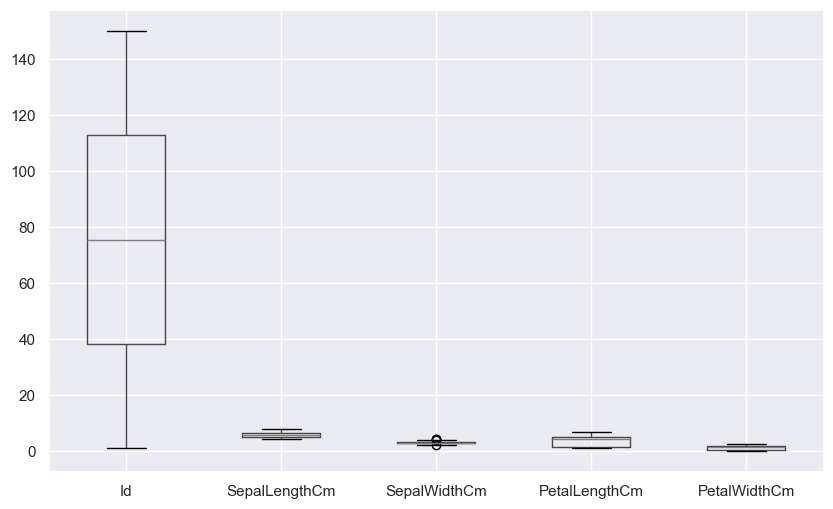

In [54]:
plt.figure(figsize=(10,6))
df.boxplot()
plt.show()

### Define X and y

In [55]:
x=df.iloc[:,:-1]
y=df['Species']

### Splitting data for training and testing

In [56]:
xtrain, xtest, ytrain, ytest=train_test_split(x,y,test_size=0.2, random_state=42)

### Train the model

In [57]:
dt= DecisionTreeClassifier(criterion='entropy')
dt.fit(xtrain, ytrain)

DecisionTreeClassifier(criterion='entropy')

### Check whether the model is underfit or overfit

In [58]:
print(f"Training Score:{dt.score(xtrain,ytrain)}")
print(f"Testing Score:{dt.score(xtest,ytest)}")

Training Score:1.0
Testing Score:1.0


### Evaluate the model

In [59]:
y_pred = dt.predict(xtest)
print(classification_report(ytest, y_pred))
print(confusion_matrix(ytest, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


### Find which features are important for decision tree prediction.

In [60]:
dt.feature_importances_


array([0.42050993, 0.        , 0.        , 0.57949007, 0.        ])

In [61]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

### Decision Tree Visualization

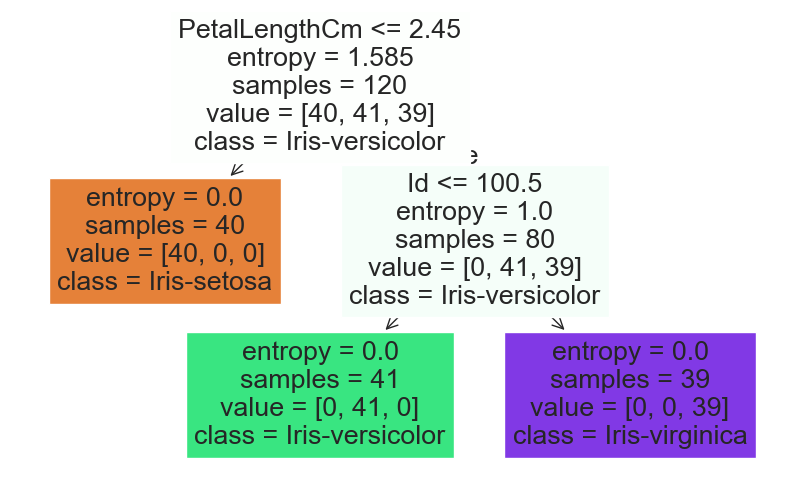

In [62]:
plt.figure(figsize=(10,6), dpi=100)
tree.plot_tree(dt, feature_names=x.columns, class_names=df['Species'].unique(), filled=True)
plt.show()

<p> conclusion: The Iris dataset was analyzed and a Decision Tree Classification model was developed using the Entropy criterion. The dataset was divided into 70% training and 30% testing data. The Decision Tree was trained to predict the Iris flower species based on its available features.

The training and testing scores were compared to check whether the model was underfitting or overfitting. Feature importance was also examined to identify which features contributed most to the model's predictions. Finally, the decision tree structure was visualized to understand the classification rules generated by the model.

Overall, the Decision Tree provides an interpretable approach for classifying Iris flower species and demonstrates how feature-based decision rules can be used for multiclass classification. </p>